In [6]:
import pandas as pd
import numpy as np

In [ ]:
dataset_dir = '../dataset/full'
products = pd.read_csv(dataset_dir+"/articles.csv")
customers = pd.read_csv(dataset_dir+"/customers.csv")
transactions = pd.read_csv(dataset_dir+"/transactions_train.csv")

In [19]:
transactions.columns

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id'], dtype='object')

In [22]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [21]:
products.columns

Index(['article_id', 'product_code', 'prod_name', 'product_type_no',
       'product_type_name', 'product_group_name', 'graphical_appearance_no',
       'graphical_appearance_name', 'colour_group_code', 'colour_group_name',
       'perceived_colour_value_id', 'perceived_colour_value_name',
       'perceived_colour_master_id', 'perceived_colour_master_name',
       'department_no', 'department_name', 'index_code', 'index_name',
       'index_group_no', 'index_group_name', 'section_no', 'section_name',
       'garment_group_no', 'garment_group_name', 'detail_desc'],
      dtype='object')

In [33]:
# in transactions df, no of customer_id who bought same article_id on different dates
# In the transactions dataframe, calculate the number of customer_id values who bought the same article_id on different dates.

# Group by article_id and customer_id, count number of unique dates; count customers with >1 purchase date for that article
repeat_buyers = (
    transactions.groupby(['article_id', 'customer_id'])['t_dat'].nunique()
    .reset_index(name='unique_dates')
)
# Filter for customers who bought the article on different dates (>1)
repeat_buyers = repeat_buyers[repeat_buyers['unique_dates'] > 1]
# Now, for each article_id, count how many unique customer_ids appear in this filtered set
repeat_customer_counts = (
    repeat_buyers.groupby('article_id')['customer_id'].nunique().reset_index(name='num_repeat_customers')
)
# Show some sample results
print(repeat_customer_counts.sort_values('num_repeat_customers', ascending=False).head(10))

       article_id  num_repeat_customers
29823   706016001                  6438
29824   706016002                  3847
947     372860001                  2881
1250    399223001                  2378
2064    464297007                  2333
56      160442007                  2201
11477   610776002                  1998
51      156231001                  1935
1265    399256001                  1911
948     372860002                  1880


In [25]:
#  H&M sells 10,141 different products every single day
'''
Let me put this in perspective with what we know:

Total unique articles in transactions: 104,547
Daily average: 10,141 unique articles
Coverage: ~9.7% of catalog sold per day'''
avg_unique_articles_per_day = transactions.groupby('t_dat')['article_id'].nunique().mean()
print(f"Average number of unique article_id per unique t_dat: {avg_unique_articles_per_day:.2f}")

Average number of unique article_id per unique t_dat: 10141.07


In [ ]:
# On average, a purchasing customer buys about 3 unique distinct articles per day.
avg_unique_articles_per_day = transactions.groupby(['t_dat', 'customer_id'])['article_id'].nunique().mean()
print(f"Average number of unique article_id per unique t_dat, customer_id: {avg_unique_articles_per_day:.2f}")

Average number of unique article_id per unique t_dat, customer_id: 3.15


In [ ]:
# On average, a purchasing customer buys about 3 unique articles per day.
avg_articles_per_day = transactions.groupby(['t_dat', 'customer_id'])['article_id'].count().mean()
print(f"Average number of articles per customer per day: {avg_articles_per_day:.2f}")

Average number of articles per customer per day: 3.50


In [11]:
# Set pandas to always display all columns for future DataFrame displays
pd.set_option('display.max_columns', None)

# Sort products by the length of 'detail_desc' from longest to shortest
products_sorted = products.assign(
    detail_desc_length=products["detail_desc"].str.len()
).sort_values("detail_desc_length", ascending=False)

products_sorted.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,perceived_colour_value_id,perceived_colour_value_name,perceived_colour_master_id,perceived_colour_master_name,department_no,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc,detail_desc_length
103467,912119001,912119,SC ATOMICA Dress,265,Dress,Garment Full body,1010016,Solid,9,Black,4,Dark,5,Black,2080,Studio Collection,A,Ladieswear,1,Ladieswear,82,Special Collections,1001,Unknown,Studio Collection. The little black number in ...,764.0
81916,806669001,806669,Grande set,270,Garment Set,Garment Full body,1010016,Solid,51,Light Pink,1,Dusty Light,4,Pink,6525,Baby Girl Jersey Fancy,G,Baby Sizes 50-98,4,Baby/Children,40,Baby Girl,1005,Jersey Fancy,Set in soft cotton. Two long-sleeved tops in e...,698.0
103465,912117002,912117,SC LILA Blouse,258,Blouse,Garment Upper body,1010016,Solid,9,Black,4,Dark,5,Black,2080,Studio Collection,A,Ladieswear,1,Ladieswear,82,Special Collections,1001,Unknown,"Studio Collection. Blouse in an airy, slightly...",692.0
103466,912117003,912117,SC LILA Blouse,258,Blouse,Garment Upper body,1010016,Solid,72,Blue,5,Bright,2,Blue,2080,Studio Collection,A,Ladieswear,1,Ladieswear,82,Special Collections,1001,Unknown,"Studio Collection. Blouse in an airy, slightly...",692.0
103058,909072001,909072,SC BACCUS leather jacket,262,Jacket,Garment Upper body,1010011,Metallic,9,Black,4,Dark,5,Black,2080,Studio Collection,A,Ladieswear,1,Ladieswear,82,Special Collections,1001,Unknown,"Studio Collection. Eye-catching, oversized jac...",663.0


In [12]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 105542 entries, 0 to 105541
Data columns (total 25 columns):
 #   Column                        Non-Null Count   Dtype 
---  ------                        --------------   ----- 
 0   article_id                    105542 non-null  int64 
 1   product_code                  105542 non-null  int64 
 2   prod_name                     105542 non-null  object
 3   product_type_no               105542 non-null  int64 
 4   product_type_name             105542 non-null  object
 5   product_group_name            105542 non-null  object
 6   graphical_appearance_no       105542 non-null  int64 
 7   graphical_appearance_name     105542 non-null  object
 8   colour_group_code             105542 non-null  int64 
 9   colour_group_name             105542 non-null  object
 10  perceived_colour_value_id     105542 non-null  int64 
 11  perceived_colour_value_name   105542 non-null  object
 12  perceived_colour_master_id    105542 non-null  int64 
 13 

# Product Hierarchy Analysis

In [13]:
# Create a list of column names that do NOT contain 'id' or 'code' (case-insensitive)
non_idcode_columns = [
    col for col in products.columns
    if 'id' not in col.lower() and 'code' not in col.lower() and '_no' not in col.lower()
]

In [32]:
products['index_group_name'].value_counts()

index_group_name
Ladieswear       39737
Baby/Children    34711
Divided          15149
Menswear         12553
Sport             3392
Name: count, dtype: int64

In [30]:
products['garment_group_name'].value_counts()

garment_group_name
Jersey Fancy                     21445
Accessories                      11519
Jersey Basic                      8126
Knitwear                          7490
Under-, Nightwear                 7441
Trousers                          6727
Blouses                           5838
Shoes                             5145
Dresses Ladies                    4874
Outdoor                           4501
Unknown                           3873
Trousers Denim                    3100
Swimwear                          2787
Socks and Tights                  2272
Shirts                            2116
Woven/Jersey/Knitted mix Baby     1965
Shorts                            1559
Dresses/Skirts girls              1541
Skirts                            1254
Special Offers                    1061
Dressed                            908
Name: count, dtype: int64

In [31]:
products['garment_group_name'].value_counts()

garment_group_name
Jersey Fancy                     21445
Accessories                      11519
Jersey Basic                      8126
Knitwear                          7490
Under-, Nightwear                 7441
Trousers                          6727
Blouses                           5838
Shoes                             5145
Dresses Ladies                    4874
Outdoor                           4501
Unknown                           3873
Trousers Denim                    3100
Swimwear                          2787
Socks and Tights                  2272
Shirts                            2116
Woven/Jersey/Knitted mix Baby     1965
Shorts                            1559
Dresses/Skirts girls              1541
Skirts                            1254
Special Offers                    1061
Dressed                            908
Name: count, dtype: int64

In [14]:
# Calculate unique value counts and sort columns by increasing nunique
nunique_per_col = [(col, products[col].nunique()) for col in non_idcode_columns]
nunique_per_col_sorted = sorted(nunique_per_col, key=lambda x: x[1])

for col, nunique in nunique_per_col_sorted:
    print(f"{col} - {nunique} unique values")
    print(products[col].value_counts().iloc[:10])
    print()

index_group_name - 5 unique values
index_group_name
Ladieswear       39737
Baby/Children    34711
Divided          15149
Menswear         12553
Sport             3392
Name: count, dtype: int64

perceived_colour_value_name - 8 unique values
perceived_colour_value_name
Dark            42706
Dusty Light     22152
Light           15739
Medium Dusty    12630
Bright           6471
Medium           5711
Undefined         105
Unknown            28
Name: count, dtype: int64

index_name - 10 unique values
index_name
Ladieswear                        26001
Divided                           15149
Menswear                          12553
Children Sizes 92-140             12007
Children Sizes 134-170             9214
Baby Sizes 50-98                   8875
Ladies Accessories                 6961
Lingeries/Tights                   6775
Children Accessories, Swimwear     4615
Sport                              3392
Name: count, dtype: int64

product_group_name - 19 unique values
product_group_name
Garm

# EDA: Product hierarchy exploration

# For each product "category" type, print its number of unique values and top value counts
hierarchy_columns = [
    'prod_name',                # product name/title (many unique, most popular at top)
    'product_type_name',        # e.g. Dress, Trousers, Sweater
    'product_group_name',       # e.g. Garment Upper body
    'graphical_appearance_name',# e.g. Solid, All over pattern
    'colour_group_name',        # e.g. Black, Dark Blue, White
    'perceived_colour_value_name',   # e.g. Dark, Dusty Light
    'perceived_colour_master_name',  # e.g. Black, Blue
    'department_name',          # e.g. Jersey, Knitwear
    'index_name',               # e.g. Ladieswear, Menswear, Baby Sizes 50-98
    'index_group_name',         # e.g. Ladieswear, Baby/Children, Menswear
    'section_name',             # sub-collection or business grouping
    'garment_group_name',       # garment group/type label
    'detail_desc'               # verbose text, many unique, but top repeats are boilerplate
]

for col in hierarchy_columns:
    nunique = products[col].nunique()
    print(f"\n{nunique}\n{col}")
    print(products[col].value_counts().head(6))
    print()

In [15]:
i=1
for detail_desc in products_sorted['detail_desc'].iloc[:5].values:
    print('index', i, 'length', len(detail_desc))
    i+=1
    print(detail_desc)

index 1 length 764
Studio Collection. The little black number in grand style, overlayered with dramatic, large flounces. Made in a slightly shimmering weave, the dress has a double-layered chest section decorated with flounces in various designs, and a frill-trimmed placket at the top with concealed buttons. The wide pleats front and back add structure and life. Overdimensioned sleeves with a wide flounce that winds all the way down to the cuffs, and wide, buttoned cuffs with a high-cut opening. Lined. The polyester content of the dress is partly recycled. Studio Collection AW20 is a tribute to the rebellious, fearless individual who dares to break the mould – an individual who plays between the extremes and finds their style amongst the androgynous, eclectic and creative.
index 2 length 698
Set in soft cotton. Two long-sleeved tops in extra-soft jersey with a concealed press-stud on one shoulder and short slits in the sides. Slightly longer and rounded at the back. One long-sleeved to

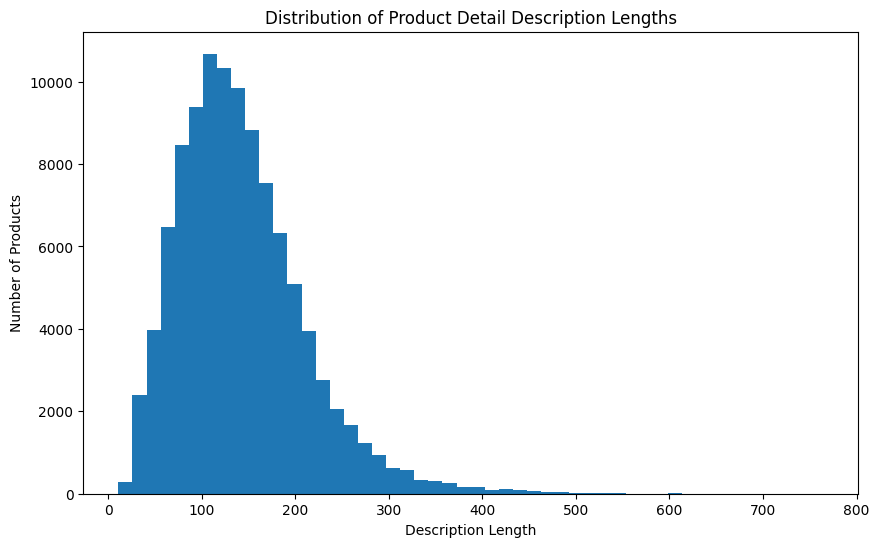

count    105126.000000
mean        142.161901
std          68.094916
min          11.000000
25%          94.000000
50%         132.000000
75%         178.000000
max         764.000000
Name: detail_desc_length, dtype: float64


In [16]:
import matplotlib.pyplot as plt

# Plot the distribution of detail_desc_length
plt.figure(figsize=(10,6))
products_sorted['detail_desc_length'].hist(bins=50)
plt.title('Distribution of Product Detail Description Lengths')
plt.xlabel('Description Length')
plt.ylabel('Number of Products')
plt.grid(False)
plt.show()

# Optionally, you can also print simple stats
print(products_sorted['detail_desc_length'].describe())